In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 4*x**2-4*x+5


In [3]:
f(4)

53

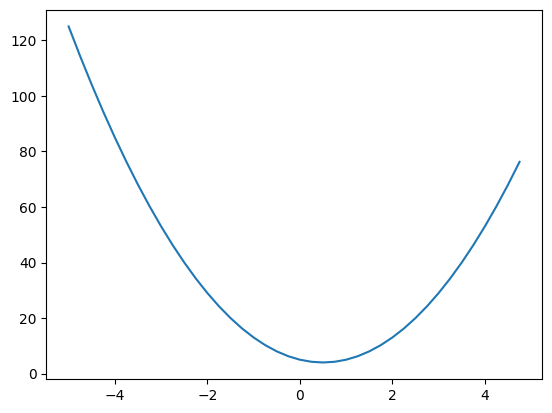

In [4]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs, ys)

In [5]:
h=0.001
x=4
(f(x+h) - f(x)) / h

28.00400000000991

In [6]:
a=2.0
b=-3.0
c=10.0
h=0.0001
d=a*b+c
print(d)


4.0


In [7]:
a=2.0
b=-3.0
c=10.0
h=0.0001
d1=a*b+c
a+=h
d2=a*b+c
print(d1, d2, (d2-d1)/h)

4.0 3.999699999999999 -3.000000000010772


In [47]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        out=Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = out.grad * 1.0
            other.grad = out.grad * 1.0
        out._backward = _backward
        return out
    def __mul__(self, other):
        out=Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad=out.grad*other.data
            other.grad=out.grad*self.data
        out._backward=_backward
        return out
    def tanh(self):
        x=self.data
        t=(math.exp(x*2)-1)/(math.exp(x*2)+1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad=out.grad*(1-t**2)
        out._backward=_backward
        return out


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f= Value(-2.0, label='f')
L=d * f; L.label = 'L'
L


Value(data=-8.0)

In [9]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [10]:
d._op

'+'

In [11]:
from graphviz import Digraph

def trace(root):
    #built a set of all the nodes and edges in the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR= left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in the graph, create a rectangular ('record') node for  it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            #if this value is a result of some operation, create an op node for it
            dot.node(name=uid+n._op, label=n._op)
            #and connect this node to it
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        #for each edge, connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

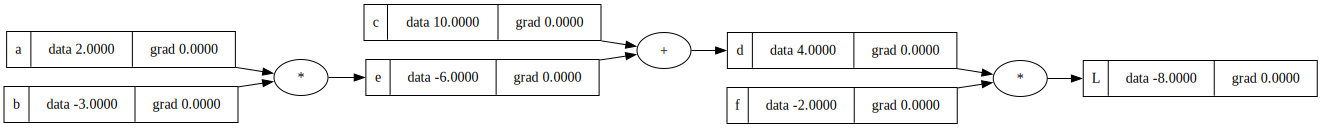

In [12]:
draw_dot(L)

In [13]:
L.grad=1.0
d.grad=L.grad * f.data
f.grad=d.grad * d.data
c.grad=d.grad * 1.0
e.grad=d.grad * 1.0
a.grad=e.grad * b.data
b.grad=e.grad * a.data

In [14]:
a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad
f.data+=0.01*f.grad

e=a*b
d=e+c
L=d*f
print(L.data)

-7.732608


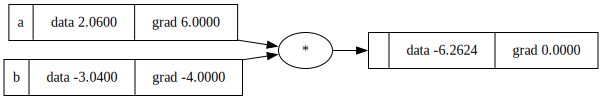

In [15]:
draw_dot(e)

In [16]:
def lol():
    h=0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f= Value(-2.0, label='f')
    L=d * f; L.label = 'L'
    L1=L.data
    a = Value(2.0+h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f= Value(-2.0, label='f')
    L=d * f; L.label = 'L'
    L2=L.data
    print((L2-L1)/h)

lol()


6.000000000021544


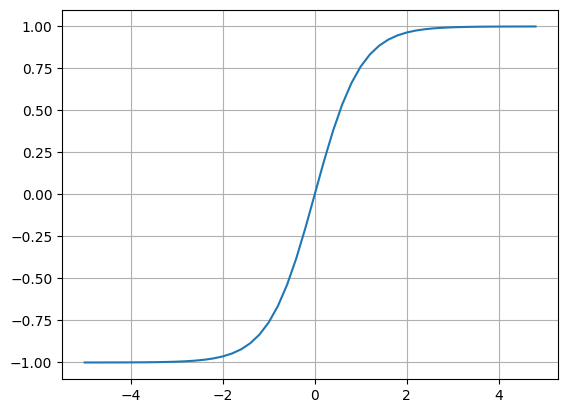

In [17]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid()

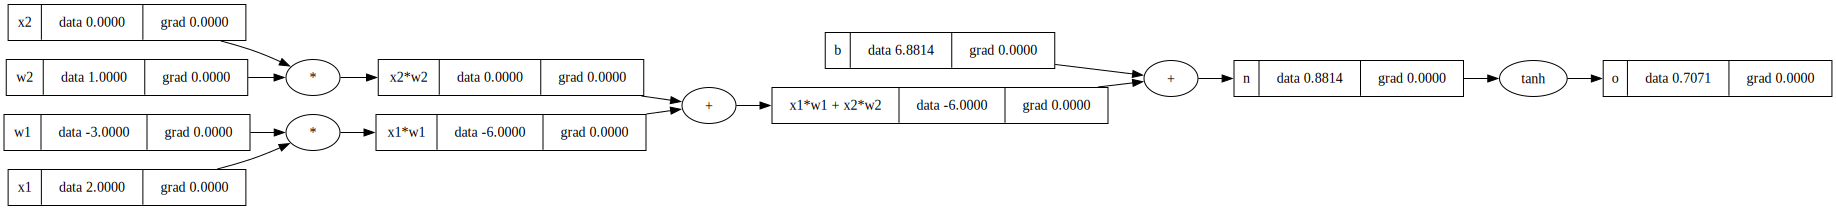

In [55]:
#input x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
w1=Value(-3.0, label='w1')
w2=Value(1.0, label='w2')
b=Value(6.8813735870195432, label='b')
x1w1=x1*w1; x1w1.label='x1*w1'
x2w2=x2*w2; x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n=x1w1x2w2+b; n.label='n'
o=n.tanh(); o.label='o'
draw_dot(o)

In [57]:
o.grad=1.0


In [59]:
o._backward()

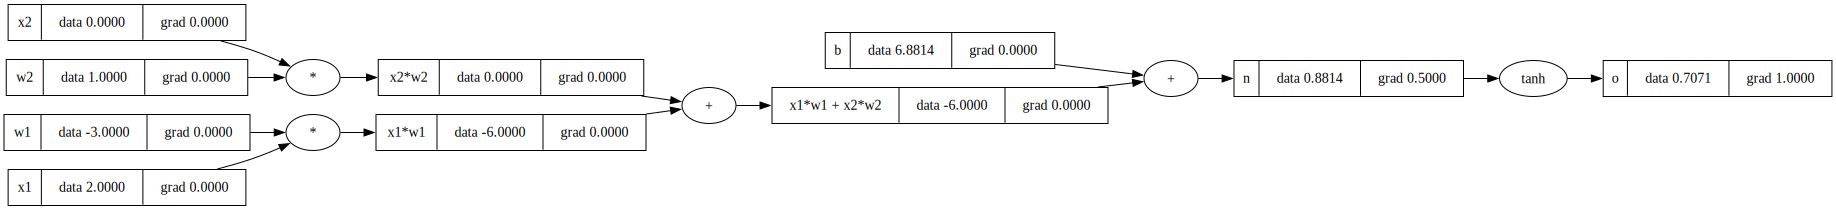

In [60]:
draw_dot(o)


In [38]:
n.grad=0.5
b.grad=n.grad * 1.0
x1w1x2w2.grad=n.grad * 1.0
x2w2.grad=x1w1x2w2.grad * 1.0
x1w1.grad=x1w1x2w2.grad * 1.0
x2.grad=x2w2.grad * w2.data
w1.grad=x1w1.grad * x1.data
w2.grad=x2w2.grad * x2.data
x1.grad=x1w1.grad * w1.data

In [27]:
o.grad=1.0

In [29]:
1-o.data**2

0.4999999999999999